# A Simple project using KNN

- Import The essential Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

- Load the Diabetes Dataset from this directory

In [2]:
data = pd.read_csv('./diabetes.csv')

- Check the head of the data.

In [3]:
data.head() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Time for some Exploratory Data Analysis (EDA)**

- Check for missing values

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


There are no missing values!

That's wierd.

- Find out if there are any anomalies.

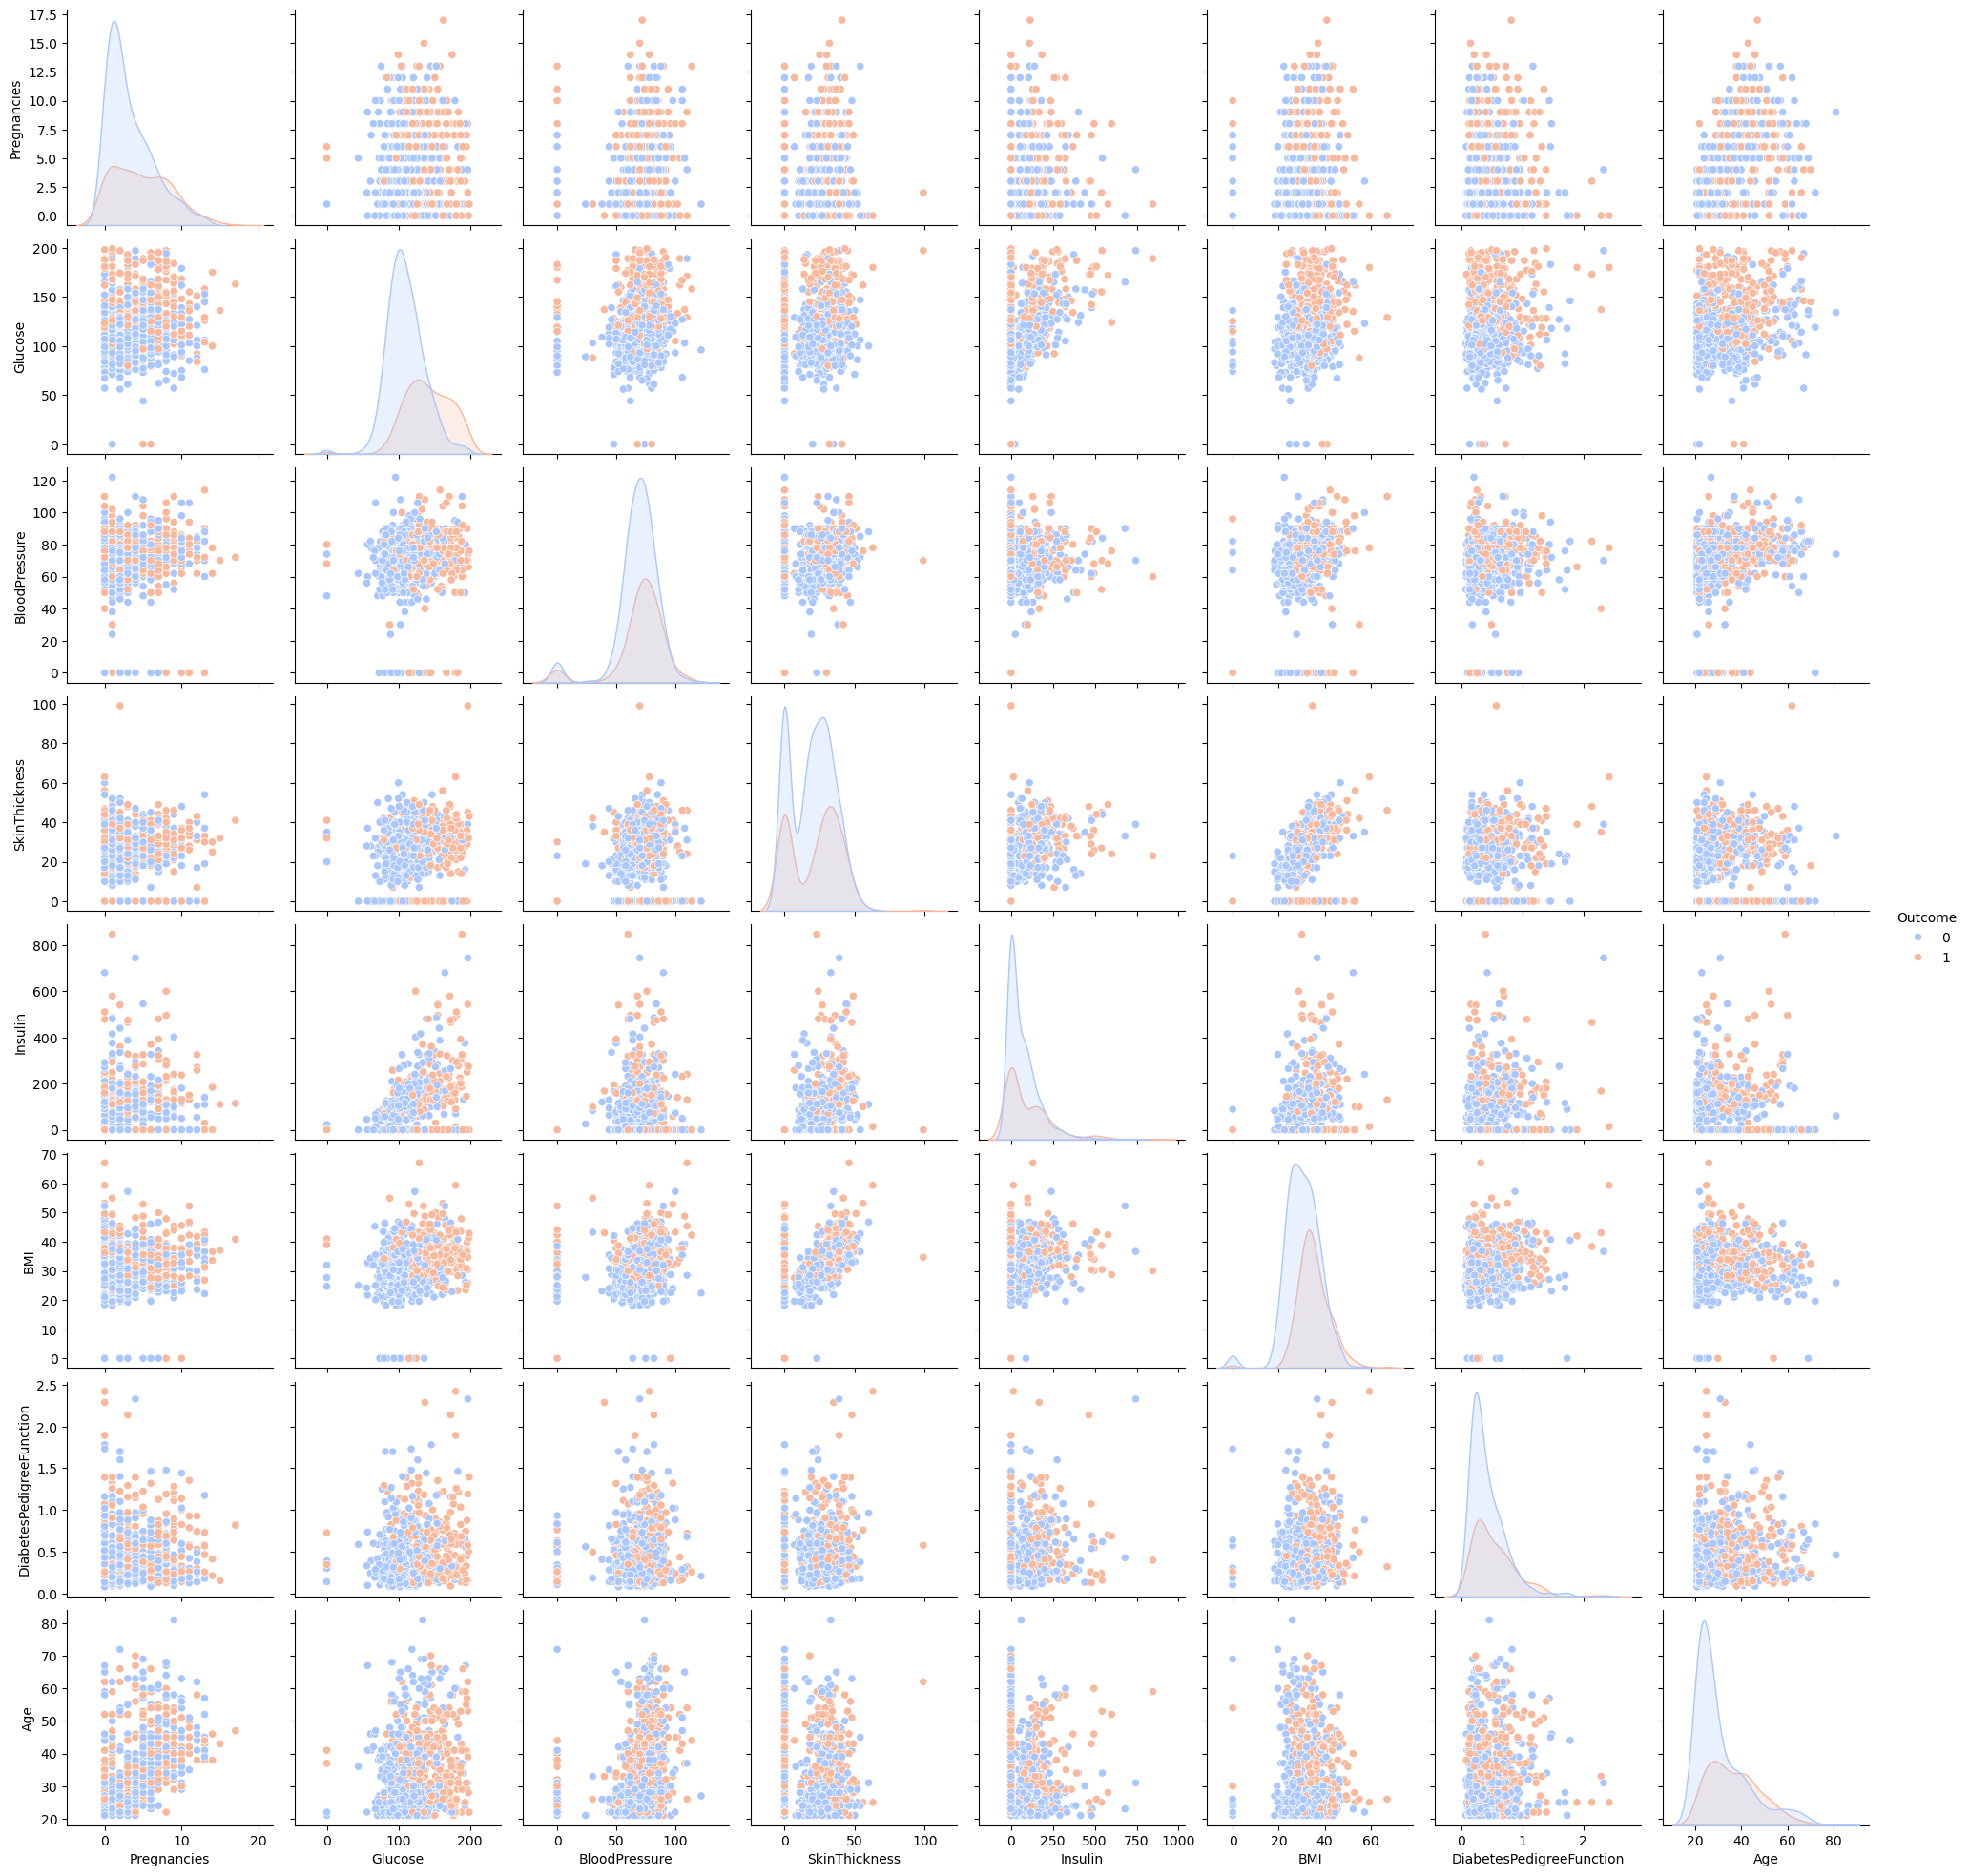

In [5]:
# THIS IS GOING TO BE A VERY LARGE PLOT
sns.pairplot(data,hue='Outcome',palette='coolwarm')

Did you see the anomalies.

Yes. There are some features that should not have `0` values.

So, sometimes when a data is reconred missing values can be stored as `0` values.

> Most of the time it's on medical datasets like the diabetes dataset we are working with. 

- Find the features that should not have `0` values.

Your ans:

- `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`

- See How many `0`s are there each features that you found.

In [6]:
invalid_zero_cols = [
    "Glucose", "BloodPressure", 
    "SkinThickness", "Insulin", "BMI"
]

(data[invalid_zero_cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

- Now replace the `0` values with `NaN` values for each of these features.

> There is a method called `replace()` that you can use to replace `0` values with `NaN` values.

In [7]:
data[invalid_zero_cols] = data[invalid_zero_cols].replace(0, np.nan)

- Now check again for `0` values.

In [8]:
(data[invalid_zero_cols] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

- Fill the missing values with the median of the column, also try to explain why you used the median, not mean.

In [9]:
data.fillna(
    value={
        "Glucose": data["Glucose"].median(),
        "BloodPressure": data["BloodPressure"].median(),
        "SkinThickness": data["SkinThickness"].median(),
        "Insulin": data["Insulin"].median(),
        "BMI": data["BMI"].median()
    },
    inplace=True
)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


- Check if all the missing values are filled.

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


- Define the Features and the `Outcome` column as target.

In [11]:
features = data.drop(columns=['Outcome'])
target = data['Outcome']

Before, going to the next step.

- See if your target column is balanced or not.

In [12]:
target.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Well, it's not balanced. But let's see how the model performs.

- Well, then Time to Scale the data. Use a scaler from scikit learn to scale the data.

In [13]:
from sklearn.preprocessing import Normalizer

scaler = Normalizer()

scaled_features = scaler.fit_transform(features)

- Here a simple task for you. transform the scaled features into a dataframe.

In [14]:
df_feat = pd.DataFrame(scaled_features,columns=data.columns[:-1])
df_feat.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.027500,0.678333,0.330000,0.160417,0.572916,0.154000,0.002874,0.229167
1,0.005801,0.493082,0.382863,0.168228,0.725120,0.154306,0.002036,0.179830
2,0.033902,0.775519,0.271220,0.122896,0.529726,0.098741,0.002848,0.135610
3,0.006612,0.588467,0.436392,0.152076,0.621527,0.185797,0.001104,0.138852
4,0.000000,0.596386,0.174127,0.152361,0.731335,0.187622,0.009960,0.143655


- Split the data into training and testing sets

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(scaled_features,target,test_size=0.30, random_state=101)

- Make a KNN model

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)

- Train the model.

In [18]:
knn.fit(X_train,y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


- The model is resy so, let's make some predictions

In [19]:
pred = knn.predict(X_test)
pred

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1])

- Create a confusion matrix and classification report.

In [20]:
from sklearn.metrics import classification_report,confusion_matrix

In [21]:
print(confusion_matrix(y_test,pred))

[[125  25]
 [ 51  30]]


In [22]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.71      0.83      0.77       150
           1       0.55      0.37      0.44        81

    accuracy                           0.67       231
   macro avg       0.63      0.60      0.60       231
weighted avg       0.65      0.67      0.65       231



- Well, that not a good sign. The model is predicting the `0` class moderately well but the model is doing horribly with the `1` class.

So, let's try to find a better K Value.

# Choosing a K Value

Write a script to find the best k value from 1 to 50.

In [23]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# odd k values from 1 to 39
k_values = range(1, 40, 2)

test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    test_scores.append(acc)

# best k
best_k = k_values[np.argmax(test_scores)]
best_score = max(test_scores)

print(f"Best k: {best_k}")
print(f"Test accuracy: {best_score:.4f}")


Best k: 17
Test accuracy: 0.7056


- Plot the accuracy scores for each k value.

Text(0, 0.5, 'Test Accuracy')

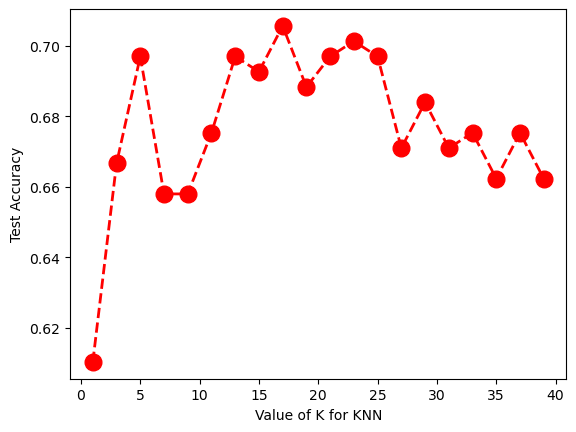

In [24]:
plt.plot(k_values,test_scores, marker='o', color='red', linestyle='dashed', linewidth=2, markersize=12)
plt.xlabel('Value of K for KNN')
plt.ylabel('Test Accuracy')

We can see that the best k value for me is 17 other than that the accuracy is actually decreasing.

- Now, retrain the model with the best k value.

In [25]:
knn = KNeighborsClassifier(n_neighbors=17)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('If, K=30,')
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

If, K=30,
[[124  26]
 [ 42  39]]
              precision    recall  f1-score   support

           0       0.75      0.83      0.78       150
           1       0.60      0.48      0.53        81

    accuracy                           0.71       231
   macro avg       0.67      0.65      0.66       231
weighted avg       0.70      0.71      0.70       231



Even though the accuracy is not that good and there is obviously some more cleaning we can do to improve the accuracy, but this is a good start. KNN doesn't need any context. So, in that case we should go try to process our data more and then apply KNN and see if we get a better accuracy. Try to fill the data with some other approach, I think that will also help.

# Great Job  🙂

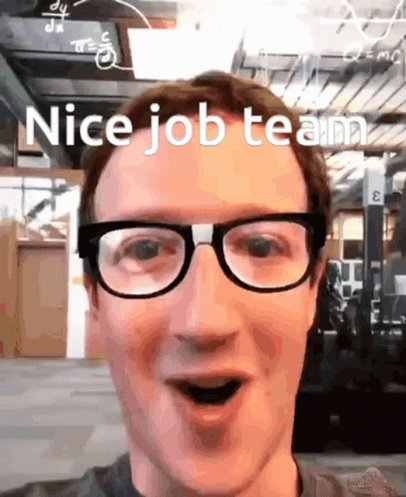